## MiniROCKET with XGBoost head with metadata concat

In [21]:
# %%
# Imports and configuration
import os
import sys
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef, brier_score_loss, 
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# --- Project Root Setup ---
def find_project_root(name='Bambino', start=None):
    if start is None:
        start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir:
            return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
if PROJECT_ROOT:
    sys.path.append(PROJECT_ROOT)
    print(f"✅ Added project root: {PROJECT_ROOT}")
else:
    print("❌ Project root not found.")
    sys.exit(1)

from config import settings
from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
from _utils_ import dataset_utils

# --- Configuration ---
DATASET_TYPE = 'normalized' # 'normalized' or 'augmented_normalized'
OUT_DIR = Path("./results_minirocket_hgb") if DATASET_TYPE == "normalized" else Path("./results_minirocket_hgb_augmented")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Check imports
try:
    from sktime.transformations.panel.rocket import MiniRocket
except ImportError:
    raise ImportError('MiniRocket not available: pip install sktime')

try:
    import shap
except ImportError:
    shap = None

# --- Helpers ---
def ds_to_numpy(ds, modalities=None):
    modality_map = {'g': 'gaze_info', 'h': 'head_info', 'f': 'face_info'}
    if modalities is None:
        modalities = ds.modalities if hasattr(ds, 'modalities') else ['g','h','f']
    
    X_list, y_list = [], []
    for inst in ds.instances:
        mats = []
        for m in modalities:
            attr = modality_map.get(m)
            if attr is None: raise ValueError(f"Unknown modality '{m}'")
            mat = getattr(inst, attr)
            mats.append(np.asarray(mat))
        
        X = np.concatenate(mats, axis=1)  # [L, D_tot]
        X_list.append(X.T)                # [D_tot, L]
        y_list.append(int(inst.trial_type))
        
    X_arr = np.stack(X_list, axis=0)      # [N, C, L]
    y_arr = np.array(y_list)
    return X_arr, y_arr

def enforce_numeric(X, name="Data"):
    """Robust data cleaner to prevent format errors"""
    if hasattr(X, "values"): X = X.values
    # Force float32 (Standard for ML)
    X = np.array(X, dtype=np.float32)
    # Handle NaNs/Infs (MiniRocket can produce Infs)
    if not np.isfinite(X).all():
        print(f"   ⚠️ {name}: Replacing infinite values...")
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X


✅ Added project root: /home/phd2/Scrivania/CorsoRepo/Bambino


In [22]:
# %% --- Load Data ---
print('\n📂 Loading datasets...')
TRAIN_PATH = settings.get_dataset_path(DATASET_TYPE, settings.training_filename)
VAL_PATH = settings.get_dataset_path(DATASET_TYPE, settings.validation_filename)
TEST_PATH = settings.get_dataset_path(DATASET_TYPE, settings.test_filename)

train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
val_ds = BoaOpenFaceDataset.load_dataset(VAL_PATH)
test_ds = BoaOpenFaceDataset.load_dataset(TEST_PATH)

print(f"Data Loaded: Train {len(train_ds)}, Val {len(val_ds)}, Test {len(test_ds)}")

# %% --- Metadata Preprocessing ---
print("\n🛠 Preparing Metadata...")
df_train = dataset_utils.dataset_to_metadata_df(train_ds)
df_val = dataset_utils.dataset_to_metadata_df(val_ds)
df_test = dataset_utils.dataset_to_metadata_df(test_ds)

for df in (df_train, df_val, df_test):
    df.dropna(subset=['label'], inplace=True)

numeric_features = ["age", "duration_s"]
cat_features = ["sex"]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
cat_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', cat_transformer, cat_features)
    ]
)

X_meta_train = preprocessor.fit_transform(df_train[numeric_features + cat_features])
X_meta_val = preprocessor.transform(df_val[numeric_features + cat_features])
X_meta_test = preprocessor.transform(df_test[numeric_features + cat_features])


📂 Loading datasets...
Data Loaded: Train 619, Val 140, Test 137

🛠 Preparing Metadata...


In [23]:
# %% --- MiniRocket Transformation ---
print("\n🚀 Running MiniRocket Transform...")
selected_modalities = ['g','h','f']

X_train_ts, y_train = ds_to_numpy(train_ds, modalities=selected_modalities)
X_val_ts, y_val = ds_to_numpy(val_ds, modalities=selected_modalities)
X_test_ts, y_test = ds_to_numpy(test_ds, modalities=selected_modalities)

mr = MiniRocket(random_state=settings.seed, num_kernels=2000, max_dilations_per_kernel=32)
X_train_feat = mr.fit_transform(X_train_ts)
X_val_feat = mr.transform(X_val_ts)
X_test_feat = mr.transform(X_test_ts)

# Concatenate
X_train_all = np.hstack([X_train_feat, X_meta_train])
X_val_all = np.hstack([X_val_feat, X_meta_val])
X_test_all = np.hstack([X_test_feat, X_meta_test])

# Sanitize
print("   Sanitizing data...")
X_train_safe = enforce_numeric(X_train_all, "Train")
X_val_safe   = enforce_numeric(X_val_all,   "Val")
X_test_safe  = enforce_numeric(X_test_all,  "Test")


🚀 Running MiniRocket Transform...
   Sanitizing data...


## HistGradientBoosting
N.B.: xgboost from xgboost crashes (maybe C++ version not stable?)

In [24]:
# %% --- HistGradientBoosting Training ---
print("\n🧠 Training HistGradientBoosting (Stable SOTA)...")

# This is the Scikit-Learn equivalent of LightGBM/XGBoost
clf = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=3,
    max_features=0.2,
    max_bins=128,
    l2_regularization=0.1,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    class_weight='balanced',
    random_state=settings.seed,
    verbose=1
)

clf.fit(X_train_safe, y_train)
print("✅ Training Complete.")

# %% --- Threshold Optimization ---
print("\n🔎 Optimizing Threshold on Validation Set...")
probs_val = clf.predict_proba(X_val_safe)[:, 1]

best_thr = 0.5
best_bal = 0.0
thresholds = np.linspace(0, 1, 101)

for thr in thresholds:
    preds = (probs_val >= thr).astype(int)
    bal = balanced_accuracy_score(y_val, preds)
    if bal > best_bal:
        best_bal = bal
        best_thr = thr
        
print(f"🎯 Best Threshold: {best_thr:.2f} (Val BalAcc: {best_bal:.4f})")

"""
Use the following setting for lighter training:
clf = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=3,  # For wide data, shallower trees often perform better
    max_bins=128,
    l2_regularization=0.1,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=settings.seed,
    scoring='loss',
    class_weight='balanced',
    verbose=1
)

"""


🧠 Training HistGradientBoosting (Stable SOTA)...
Binning 0.327 GB of training data: 7.762 s
Binning 0.036 GB of validation data: 0.280 s
Fitting gradient boosted rounds:
Fit 34 trees in 10.459 s, (227 total leaves)
Time spent computing histograms: 1.884s
Time spent finding best splits:  0.411s
Time spent applying splits:      0.005s
Time spent predicting:           0.001s
✅ Training Complete.

🔎 Optimizing Threshold on Validation Set...
🎯 Best Threshold: 0.70 (Val BalAcc: 0.6116)


"\nUse the following setting for lighter training:\nclf = HistGradientBoostingClassifier(\n    max_iter=300,\n    learning_rate=0.05,\n    max_depth=3,  # For wide data, shallower trees often perform better\n    max_bins=128,\n    l2_regularization=0.1,\n    early_stopping=True,\n    validation_fraction=0.1,\n    n_iter_no_change=20,\n    random_state=settings.seed,\n    scoring='loss',\n    class_weight='balanced',\n    verbose=1\n)\n\n"

## Test & Plots

📝 Running Final Evaluation on Test Set (MiniRocket)...

--- TEST SET RESULTS ---
Balanced Accuracy: 0.4843
MCC: -0.0313
Brier Score: 0.2165

Classification Report:
              precision    recall  f1-score   support

           0     0.1909    0.7778    0.3066        27
           1     0.7778    0.1909    0.3066       110

    accuracy                         0.3066       137
   macro avg     0.4843    0.4843    0.3066       137
weighted avg     0.6621    0.3066    0.3066       137



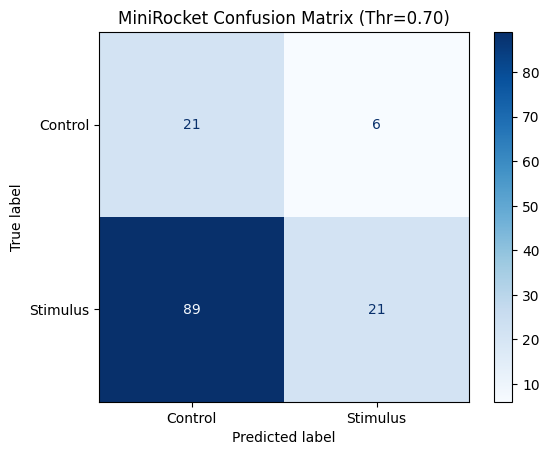

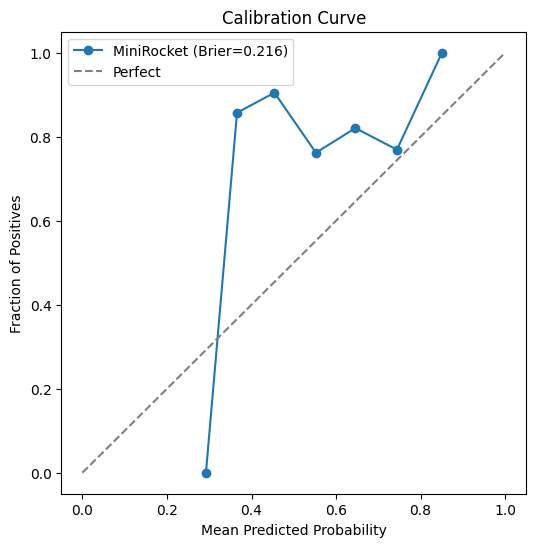


👶 Per-Baby Analysis & Age Correlation...

--- Per-Baby Balanced Accuracy and F1 Scores ---
------------------------------------------------------------
BabyID          | Age   | Sex | Balanced Acc | F1 Score
------------------------------------------------------------
bam1_026        | 6.54  | F   | 0.3438       | 0.2857
bam1_044        | 6.08  | M   | 0.3750       | 0.0000
bam1_005        | 5.42  | F   | 0.4062       | 0.1111
bam1_018        | 4.96  | M   | 0.4375       | 0.2105
bam1_020        | 4.83  | F   | 0.5312       | 0.4545
bam1_008        | 6.70  | F   | 0.6333       | 0.4211
bam1_024        | 6.41  | F   | 0.7000       | 0.5714
------------------------------------------------------------


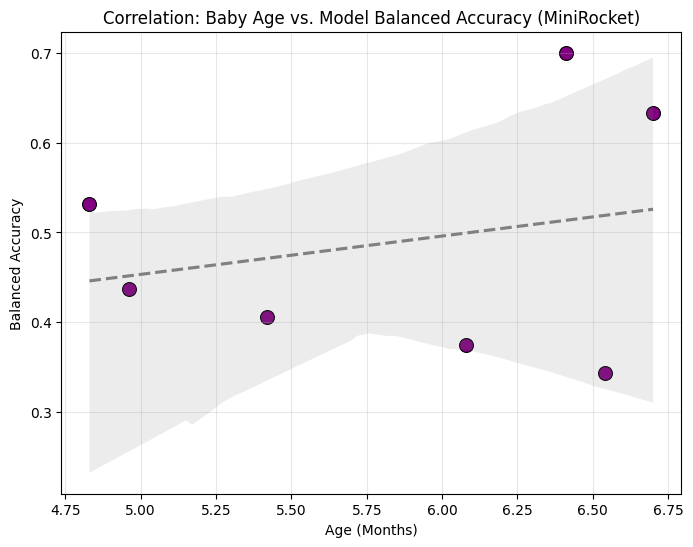

In [25]:
# %% --- Final Test Evaluation ---
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (balanced_accuracy_score, matthews_corrcoef, 
                             confusion_matrix, classification_report, 
                             ConfusionMatrixDisplay, brier_score_loss, 
                             f1_score)

print("📝 Running Final Evaluation on Test Set (MiniRocket)...")

# 1. Predictions
# Assuming X_test_safe is already prepared (NaNs handled)
probs_test = clf.predict_proba(X_test_safe)[:, 1]
y_pred_test = (probs_test >= best_thr).astype(int)

# 2. Global Metrics
bal_test = balanced_accuracy_score(y_test, y_pred_test)
mcc_test = matthews_corrcoef(y_test, y_pred_test)
brier_test = brier_score_loss(y_test, probs_test)

print("\n--- TEST SET RESULTS ---")
print(f"Balanced Accuracy: {bal_test:.4f}")
print(f"MCC: {mcc_test:.4f}")
print(f"Brier Score: {brier_test:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=4))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Stimulus"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"MiniRocket Confusion Matrix (Thr={best_thr:.2f})")
plt.savefig(OUT_DIR / "minirocket_confusion_matrix.png")
plt.show()

# 4. Calibration Curve (Added to match ResNet specs)
prob_true, prob_pred = calibration_curve(y_test, probs_test, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label=f'MiniRocket (Brier={brier_test:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.savefig(OUT_DIR / "minirocket_calibration_curve.png")
plt.show()

# %% --- Detailed Per-Baby Analysis & Age Correlation ---
print("\n👶 Per-Baby Analysis & Age Correlation...")

# Create mapping (pt_id, trial_id) -> Index in X_test_safe
# This ensures we pull the correct feature vector for the correct metadata row
map_key_to_idx = {
    (str(inst.pt_id), int(inst.trial_id)): i
    for i, inst in enumerate(test_ds.instances)
}

pt_ids = df_test["pt_id"].unique()
per_baby_details = [] 

for pid in pt_ids:
    sub = df_test[df_test["pt_id"] == pid]
    if len(sub) < 1: continue # Handle babies with single trials if necessary

    # Find indices for this baby
    idxs = []
    for _, row in sub.iterrows():
        key = (str(row["pt_id"]), int(row["trial_id"]))
        if key in map_key_to_idx:
            idxs.append(map_key_to_idx[key])
    
    if not idxs: continue
    
    # Extract Data for this baby
    X_sub_safe = X_test_safe[idxs]
    y_sub = sub["label"].astype(int)
    
    # Predict
    sub_probs = clf.predict_proba(X_sub_safe)[:, 1]
    sub_preds = (sub_probs >= best_thr).astype(int)
    
    bal_acc = balanced_accuracy_score(y_sub, sub_preds)
    f1 = f1_score(y_sub, sub_preds, zero_division=0)
    
    # Metadata
    age = sub["age"].iloc[0] if "age" in sub.columns else 0
    sex_val = sub["sex"].iloc[0] if "sex" in sub.columns else "N/A"
    
    # Normalize Sex string (0->F, 1->M)
    sex_str = str(sex_val)
    if sex_str == "0": sex_str = "F"
    elif sex_str == "1": sex_str = "M"

    per_baby_details.append((pid, age, sex_str, bal_acc, f1))

# Sort by balanced accuracy Score
per_baby_details.sort(key=lambda x: x[3])

# Print Table (ResNet Formatting)
print("\n--- Per-Baby Balanced Accuracy and F1 Scores ---")
print("-" * 60)
print(f"{'BabyID':<15} | {'Age':<5} | {'Sex':<3} | {'Balanced Acc':<12} | {'F1 Score'}")
print("-" * 60)
for pid, age, sex, bal_acc, f1 in per_baby_details:
    print(f"{pid:<15} | {age:<5.2f} | {sex:<3} | {bal_acc:<12.4f} | {f1:.4f}")
print("-" * 60)

# 5. Scatter Plot: Age vs Balanced Accuracy (ResNet Visual Style)
ages = [x[1] for x in per_baby_details]
bal_accs = [x[3] for x in per_baby_details]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=ages, y=bal_accs, s=100, color='purple', edgecolor='black')
sns.regplot(x=ages, y=bal_accs, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title("Correlation: Baby Age vs. Model Balanced Accuracy (MiniRocket)")
plt.xlabel("Age (Months)")
plt.ylabel("Balanced Accuracy")
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR / "minirocket_age_correlation.png")
plt.show()

## Shap explainability

In [26]:
# %% --- SHAP ---
if shap is not None:
    print("\n✨ Computing SHAP Values...")
    try:
        # Create Feature Names
        mr_names = [f'MR_{i}' for i in range(X_train_feat.shape[1])]
        ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
        meta_names = numeric_features + list(ohe.get_feature_names_out(cat_features))
        all_names = mr_names + meta_names
        
        X_test_df = pd.DataFrame(X_test_safe, columns=all_names)
        
        # HistGradientBoosting works with generic Explainer
        # We use a subset of test data (e.g. 100 samples) to speed up if needed
        explainer = shap.Explainer(clf.predict, X_test_df)
        shap_values = explainer(X_test_df.iloc[:50]) # Use subset for speed
        
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_test_df.iloc[:50], max_display=20, show=False)
        plt.title("Top 20 Features (MiniRocket + HGB)")
        plt.savefig(OUT_DIR / "hgb_shap_summary.png", bbox_inches='tight', dpi=300)
        plt.show()
    except Exception as e:
        print(f"SHAP Warning: {e}")


✨ Computing SHAP Values...
SHAP Warning: max_evals=500 is too low for the Permutation explainer, it must be at least 2 * num_features + 1 = 146669!
